# Convolutional Neural Networks (CNNs) using Cat vs Dog Dataset in TensorFlow/Keras

## Importing Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

## Loading the Dataset

In [2]:
path = kagglehub.dataset_download("salader/dogsvscats")

100%|██████████| 1.06G/1.06G [00:10<00:00, 114MB/s]

Extracting files...


In [3]:
os.listdir(path)

['test', 'train', 'catsvsdogs']

In [4]:
path

'/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1'

In [7]:
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

train_data = keras.utils.image_dataset_from_directory(
    directory=train_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

test_data = keras.utils.image_dataset_from_directory(
    directory=test_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## Normalizing Data

In [8]:
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [9]:
train_data = train_data.map(process)
test_data = test_data.map(process)

In [32]:
train_data.element_spec[0].shape

TensorShape([None, 256, 256, 3])

In [33]:
train_data.element_spec

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [30]:
train_data

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Viewing Sample Images

### View Train Dataset Samples

In [25]:
# taking random 1 image
def train_data_plot_image():
    for images, labels in train_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Train data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

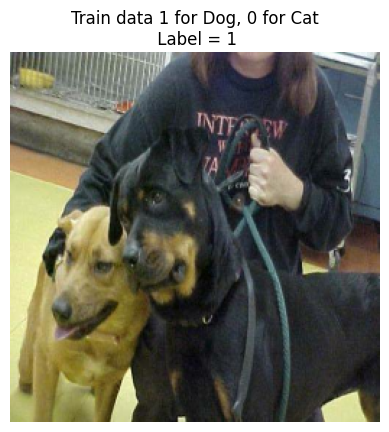

In [26]:
train_data_plot_image()

### Viewing Test Dataset Random Samples

In [27]:
# taking random 1 image
def test_data_plot_image():
    for images, labels in test_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Test data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

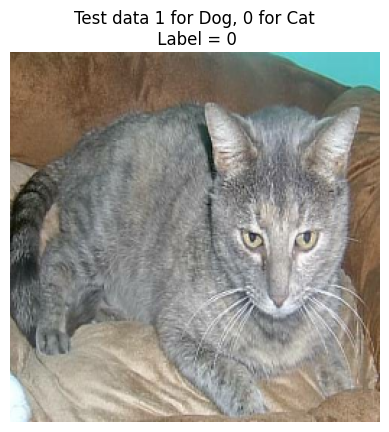

In [28]:
test_data_plot_image()